# Chapter 0b — Prior sensitivity

This notebook assesses sensitivity of the framework to the prior specification.

The scientific model and data-generating process are held fixed. The same independently
generated datasets are fitted under several prior specifications so that differences
between fits reflect the priors rather than different simulated samples.

The analysis uses the supplied-axis one-sided corruption setting

$$
n=3000,\qquad
p=5,\qquad
\beta_0=-0.8,\qquad
\boldsymbol{\beta}=(1.5,-1.2,0.8,-0.6,0),
$$

with

$$
R=\{\mathbf{x}:x_5>0.8\},\qquad q=0.35.
$$

The boundary predictor is therefore null in the latent-response model. This is a targeted
robustness analysis rather than a separate simulation experiment.

## Prior specifications

Three prior specifications are compared.

**Baseline** uses the priors from the main analysis:

$$
\beta_0\sim\mathcal N(0,2^2),\qquad
\beta_j\sim\mathcal N(0,1),\qquad
c\sim\mathcal N(0,1),\qquad
q\sim\mathrm{Beta}(2,5).
$$

**Diffuse coefficient and threshold priors** widen the continuous prior scales while leaving the prior on \(q\) unchanged:

$$
\beta_0\sim\mathcal N(0,4^2),\qquad
\beta_j\sim\mathcal N(0,2^2),\qquad
c\sim\mathcal N(0,2^2),\qquad
q\sim\mathrm{Beta}(2,5).
$$

**Uniform corruption-rate prior** keeps the coefficient and threshold priors at baseline and replaces the prior on \(q\) with

$$
q\sim\mathrm{Beta}(1,1).
$$

This separates sensitivity to the continuous prior scales from sensitivity to the prior placed directly on the corruption rate.

In [1]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")

try:
    from cmdstanpy import CmdStanModel

    STAN_AVAILABLE = True
    print("Stan available — prior sensitivity can be run.")
except ImportError:
    STAN_AVAILABLE = False
    print("cmdstanpy is not installed in this environment.")


SEED = 42

# Chapter 0b prior-sensitivity setting.
N = 3000
P = 5
TRUE_BETA0 = -0.8
TRUE_BETA = np.array([1.5, -1.2, 0.8, -0.6, 0.0])
TRUE_C = 0.8
TRUE_Q = 0.35

# x5 is column 4 in Python.
BOUNDARY_DIM = 4
KAPPA = 5.0

# Reuse the same 10 datasets across all prior specifications.
N_REPS = 10

CHAINS = 4
ITER_WARMUP = 1000
ITER_SAMPLING = 2000
ADAPT_DELTA = 0.95
MAX_TREEDEPTH = 12

PARALLEL_CHAINS = min(
    CHAINS,
    os.cpu_count() or CHAINS,
)

OUTPUT_DIR = (
    Path("high_replication")
    / "chapter0b_prior_sensitivity"
)

FIT_DIR = OUTPUT_DIR / "stan_fits"
FIG_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_CSV = (
    OUTPUT_DIR
    / "prior_sensitivity_results.csv"
)

print(f"Output directory: {OUTPUT_DIR.resolve()}")
print(f"Number of paired datasets: {N_REPS}")

Stan available — prior sensitivity can be run.
Output directory: /Users/demikramer/Desktop/MLDS_Demi_Kramer_Imperial copy/high_replication/chapter0b_prior_sensitivity
Number of paired datasets: 10


In [2]:
# Prior specifications compared on the same paired datasets.
PRIOR_SPECS = {
    "baseline": {
        "beta0_sd": 2.0,
        "beta_sd": 1.0,
        "c_mean": 0.0,
        "c_sd": 1.0,
        "q_a": 2.0,
        "q_b": 5.0,
    },
    "diffuse": {
        "beta0_sd": 4.0,
        "beta_sd": 2.0,
        "c_mean": 0.0,
        "c_sd": 2.0,
        "q_a": 2.0,
        "q_b": 5.0,
    },
    "q_uniform": {
        "beta0_sd": 2.0,
        "beta_sd": 1.0,
        "c_mean": 0.0,
        "c_sd": 1.0,
        "q_a": 1.0,
        "q_b": 1.0,
    },
}

pd.DataFrame(PRIOR_SPECS).T

,beta0_sd,beta_sd,c_mean,c_sd,q_a,q_b
baseline,2.0,1.0,0.0,1.0,2.0,5.0
diffuse,4.0,2.0,0.0,2.0,2.0,5.0
q_uniform,2.0,1.0,0.0,1.0,1.0,1.0


## Stan model with prior hyperparameters supplied as data

The likelihood is the same one-sided $1\to0$ marginal likelihood used in Chapter 0. The prior hyperparameters are supplied as data so that the same model can be fitted under each of the three prior specifications above.

In [3]:
stan_code_prior_sensitivity = r'''
data {
  int<lower=0> n;
  int<lower=0> p;
  matrix[n, p] X;
  array[n] int<lower=0, upper=1> y;
  int<lower=1, upper=p> boundary_dim;
  real kappa;

  real<lower=0> beta0_prior_sd;
  real<lower=0> beta_prior_sd;
  real c_prior_mean;
  real<lower=0> c_prior_sd;
  real<lower=0> q_prior_a;
  real<lower=0> q_prior_b;
}

parameters {
  real beta0;
  vector[p] beta;
  real c;
  real<lower=0, upper=1> q;
}

model {
  beta0 ~ normal(0, beta0_prior_sd);
  beta  ~ normal(0, beta_prior_sd);
  c     ~ normal(c_prior_mean, c_prior_sd);
  q     ~ beta(q_prior_a, q_prior_b);

  {
    vector[n] eta   = beta0 + X * beta;
    vector[n] log_r = log_inv_logit(kappa * (X[, boundary_dim] - c));

    for (i in 1:n) {
      real log_p  = log_inv_logit(eta[i]);
      real log_1p = log1m_inv_logit(eta[i]);
      real log_qr = log(q) + log_r[i];

      if (y[i] == 1) {
        target += log1m_exp(log_qr) + log_p;
      } else {
        target += log_sum_exp(log_1p, log_qr + log_p);
      }
    }
  }
}

generated quantities {
  vector[n] z_prob;
  vector[n] r;
  vector[n] log_lik;

  {
    vector[n] eta   = beta0 + X * beta;
    vector[n] log_r = log_inv_logit(kappa * (X[, boundary_dim] - c));

    for (i in 1:n) {
      real log_p  = log_inv_logit(eta[i]);
      real log_1p = log1m_inv_logit(eta[i]);
      real log_qr = log(q) + log_r[i];

      r[i] = exp(log_r[i]);

      if (y[i] == 1) {
        z_prob[i]  = 0;
        log_lik[i] = log1m_exp(log_qr) + log_p;
      } else {
        real log_corr = log_qr + log_p;
        real log_tot  = log_sum_exp(log_1p, log_corr);
        z_prob[i]  = exp(log_corr - log_tot);
        log_lik[i] = log_tot;
      }
    }
  }
}
'''

STAN_FILE = OUTPUT_DIR / "corruption_model_axis_PRIOR_SENSITIVITY.stan"
STAN_FILE.write_text(stan_code_prior_sensitivity)
print(f"Wrote: {STAN_FILE}")

if STAN_AVAILABLE:
    model_prior = CmdStanModel(stan_file=str(STAN_FILE))
    print("Stan model compiled.")

16:51:04 - cmdstanpy - INFO - compiling stan file /var/folders/hk/s02zbvd931b5x94gx2t9sh940000gn/T/tmpxqeh69gu/tmpqn69t7p3.stan to exe file /Users/demikramer/Desktop/MLDS_Demi_Kramer_Imperial copy/high_replication/chapter0b_prior_sensitivity/corruption_model_axis_PRIOR_SENSITIVITY


Wrote: high_replication/chapter0b_prior_sensitivity/corruption_model_axis_PRIOR_SENSITIVITY.stan


16:51:09 - cmdstanpy - INFO - compiled model executable: /Users/demikramer/Desktop/MLDS_Demi_Kramer_Imperial copy/high_replication/chapter0b_prior_sensitivity/corruption_model_axis_PRIOR_SENSITIVITY


Stan model compiled.


## Data-generating process

Each replicate is generated once and then reused across all prior specifications. This paired design ensures that differences between fits reflect the priors rather than ordinary between-dataset variation.

In [4]:
def logistic_dgp(n, rng, p=P):
    X = rng.normal(0, 1, size=(n, p))
    eta = TRUE_BETA0 + X @ TRUE_BETA
    prob = 1.0 / (1.0 + np.exp(-eta))
    y_true = rng.binomial(1, prob).astype(int)
    return X, y_true


def corrupt_one_sided(y_true, region, q, rng):
    # Only true positives inside the region are eligible to flip.
    eligible = (y_true == 1) & region
    flips = eligible & (rng.random(len(y_true)) < q)

    y_obs = y_true.copy()
    y_obs[flips] = 0

    return y_obs, flips


def generate_replicate(rep):
    # Keep the response and corruption draws on separate reproducible streams.
    data_seed = SEED + 1000 + rep
    corrupt_seed = SEED + 100000 + rep

    rng_data = np.random.default_rng(data_seed)
    rng_corrupt = np.random.default_rng(corrupt_seed)

    # Generate the clean response first, then apply the one-sided corruption.
    X, y_true = logistic_dgp(N, rng_data)
    region = X[:, BOUNDARY_DIM] > TRUE_C

    y_obs, flips = corrupt_one_sided(
        y_true,
        region,
        TRUE_Q,
        rng_corrupt,
    )

    # This exact dataset is reused for each prior specification.
    return {
        "X": X,
        "y_true": y_true,
        "region": region,
        "y_obs": y_obs,
        "flips": flips,
        "data_seed": data_seed,
        "corrupt_seed": corrupt_seed,
    }


# Quick check that the generated sample looks as expected.
example = generate_replicate(1)

print(
    f"Example replicate: region={example['region'].mean():.3f}, "
    f"eligible={((example['y_true'] == 1) & example['region']).sum()}, "
    f"corruptions={example['flips'].sum()}"
)

Example replicate: region=0.216, eligible=243, corruptions=88


In [5]:
def make_stan_data(dataset, prior):
    return {
        "n": N,
        "p": P,
        "X": dataset["X"].tolist(),
        "y": dataset["y_obs"].tolist(),
        "boundary_dim": BOUNDARY_DIM + 1,  # Stan indexes from 1
        "kappa": KAPPA,
        "beta0_prior_sd": prior["beta0_sd"],
        "beta_prior_sd": prior["beta_sd"],
        "c_prior_mean": prior["c_mean"],
        "c_prior_sd": prior["c_sd"],
        "q_prior_a": prior["q_a"],
        "q_prior_b": prior["q_b"],
    }


def core_diagnostics(fit):
    summary = fit.summary()

    # Apply the diagnostic gate to the parameters used for recovery.
    core_names = (
        ["beta0"]
        + [f"beta[{j}]" for j in range(1, P + 1)]
        + ["c", "q"]
    )
    core = summary.loc[[x for x in core_names if x in summary.index]]

    # Allow for small differences in CmdStanPy summary column names.
    normalized = {
        str(col).lower().replace("_", "").replace("-", ""): col
        for col in core.columns
    }

    rhat_col = normalized.get("rhat")

    # Use bulk ESS where available, with N_Eff as a fallback.
    ess_col = None
    for key in ("essbulk", "bulkeffsamplesize", "neff"):
        if key in normalized:
            ess_col = normalized[key]
            break

    max_rhat = np.nan
    min_bulk_ess = np.nan

    if rhat_col is not None:
        max_rhat = float(
            np.nanmax(core[rhat_col].to_numpy(dtype=float))
        )

    if ess_col is not None:
        min_bulk_ess = float(
            np.nanmin(core[ess_col].to_numpy(dtype=float))
        )

    method_vars = fit.method_variables()

    divergences = int(
        np.asarray(method_vars.get("divergent__", 0)).sum()
    )

    td = np.asarray(method_vars.get("treedepth__", []))
    treedepth_hits = (
        int((td >= MAX_TREEDEPTH).sum())
        if td.size
        else 0
    )

    diagnostic_pass = (
        np.isfinite(max_rhat)
        and max_rhat <= 1.05
        and np.isfinite(min_bulk_ess)
        and min_bulk_ess >= 100
        and divergences == 0
        and treedepth_hits == 0
    )

    return {
        "max_rhat": max_rhat,
        "min_bulk_ess": min_bulk_ess,
        "divergences": divergences,
        "treedepth_hits": treedepth_hits,
        "diagnostic_pass": bool(diagnostic_pass),
    }


def posterior_metrics(fit, dataset):
    beta0 = fit.stan_variable("beta0")
    beta = fit.stan_variable("beta")
    c_draws = fit.stan_variable("c")
    q_draws = fit.stan_variable("q")

    # Average the observation-level corruption probabilities over posterior draws.
    z_mean = fit.stan_variable("z_prob").mean(axis=0)

    beta_mean = beta.mean(axis=0)

    c_lo, c_hi = np.percentile(
        c_draws,
        [2.5, 97.5],
    )
    q_lo, q_hi = np.percentile(
        q_draws,
        [2.5, 97.5],
    )

    # Localisation is evaluated among observed negatives, where corruption is possible.
    neg = dataset["y_obs"] == 0
    k = int(dataset["flips"].sum())

    auc = roc_auc_score(
        dataset["flips"][neg],
        z_mean[neg],
    )

    # Precision@k uses the actual number of corruptions in that dataset.
    if k > 0:
        top = np.argsort(-z_mean[neg])[:k]
        precision_k = float(
            dataset["flips"][neg][top].mean()
        )
    else:
        precision_k = np.nan

    out = {
        "region_share": float(
            dataset["region"].mean()
        ),
        "eligible_positives": int(
            (
                (dataset["y_true"] == 1)
                & dataset["region"]
            ).sum()
        ),
        "corruptions": int(
            dataset["flips"].sum()
        ),
        "effective_flip_rate": float(
            dataset["flips"].mean()
        ),

        "beta0_mean": float(
            beta0.mean()
        ),
        "beta0_abs_error": float(
            abs(beta0.mean() - TRUE_BETA0)
        ),
        "beta_rmse": float(
            np.sqrt(
                np.mean(
                    (beta_mean - TRUE_BETA) ** 2
                )
            )
        ),

        "c_mean": float(
            c_draws.mean()
        ),
        "c_abs_error": float(
            abs(c_draws.mean() - TRUE_C)
        ),
        "c_sd": float(
            c_draws.std(ddof=1)
        ),
        "c_ci_width": float(
            c_hi - c_lo
        ),
        "c_coverage": bool(
            c_lo <= TRUE_C <= c_hi
        ),

        "q_mean": float(
            q_draws.mean()
        ),
        "q_abs_error": float(
            abs(q_draws.mean() - TRUE_Q)
        ),
        "q_sd": float(
            q_draws.std(ddof=1)
        ),
        "q_ci_width": float(
            q_hi - q_lo
        ),
        "q_coverage": bool(
            q_lo <= TRUE_Q <= q_hi
        ),

        "localisation_auc": float(auc),
        "precision_at_k": precision_k,
    }

    out.update(core_diagnostics(fit))
    return out

## Run the paired sensitivity analysis

The checkpoint CSV is updated after each completed fit. If execution is interrupted,
rerunning this cell skips replicate/prior combinations that have already been completed.

With 10 datasets and 3 prior specifications, the analysis requires 30 Stan fits.

In [6]:
if not STAN_AVAILABLE:
    raise RuntimeError("cmdstanpy/Stan is required to run this notebook.")


# Pick up from the last completed fit if this cell was interrupted.
if RESULTS_CSV.exists():
    results = pd.read_csv(RESULTS_CSV)
    print(f"Loaded checkpoint with {len(results)} completed fits.")
else:
    results = pd.DataFrame()


# Keep track of the replicate/prior combinations that are already done.
completed = set()

if len(results):
    completed = set(
        zip(
            results["rep"].astype(int),
            results["prior"].astype(str),
        )
    )

rows = results.to_dict("records") if len(results) else []


# Generate each dataset once, then fit that exact dataset under all three priors.
for rep in range(1, N_REPS + 1):
    dataset = generate_replicate(rep)

    print(
        f"\nDataset {rep}/{N_REPS}: "
        f"region={dataset['region'].mean():.3f}, "
        f"corruptions={dataset['flips'].sum()}"
    )

    for prior_idx, (prior_name, prior_spec) in enumerate(PRIOR_SPECS.items()):
        key = (rep, prior_name)

        # Do not rerun fits already stored in the checkpoint.
        if key in completed:
            print(f"  {prior_name:<10} — checkpoint found, skipping")
            continue

        print(f"  {prior_name:<10} — fitting")

        # Keep the Stan output separated by dataset and prior.
        fit_output = FIT_DIR / f"rep_{rep:02d}" / prior_name
        fit_output.mkdir(parents=True, exist_ok=True)

        fit = model_prior.sample(
            data=make_stan_data(dataset, prior_spec),
            chains=CHAINS,
            parallel_chains=PARALLEL_CHAINS,
            iter_warmup=ITER_WARMUP,
            iter_sampling=ITER_SAMPLING,
            seed=SEED + 200000 + rep * 100 + prior_idx,
            adapt_delta=ADAPT_DELTA,
            max_treedepth=MAX_TREEDEPTH,
            output_dir=str(fit_output),
            show_progress=False,
        )

        # Store the recovery metrics and diagnostics for this fit.
        row = {
            "rep": rep,
            "prior": prior_name,
            "data_seed": dataset["data_seed"],
            "corrupt_seed": dataset["corrupt_seed"],
        }

        row.update(posterior_metrics(fit, dataset))
        rows.append(row)

        # Save after every fit so a long run can be resumed without losing work.
        results = (
            pd.DataFrame(rows)
            .sort_values(["rep", "prior"])
            .reset_index(drop=True)
        )
        results.to_csv(RESULTS_CSV, index=False)

        print(
            f"    c={row['c_mean']:.3f}, "
            f"q={row['q_mean']:.3f}, "
            f"beta RMSE={row['beta_rmse']:.3f}, "
            f"AUC={row['localisation_auc']:.3f}, "
            f"diag_pass={row['diagnostic_pass']}"
        )


print(f"\nFinished. Checkpoint saved to: {RESULTS_CSV}")


Dataset 1/10: region=0.216, corruptions=88
  baseline   — fitting


16:56:38 - cmdstanpy - INFO - CmdStan start processing
16:56:38 - cmdstanpy - INFO - Chain [1] start processing
16:56:38 - cmdstanpy - INFO - Chain [2] start processing
16:56:38 - cmdstanpy - INFO - Chain [3] start processing
16:56:38 - cmdstanpy - INFO - Chain [4] start processing
16:56:55 - cmdstanpy - INFO - Chain [2] done processing
16:56:55 - cmdstanpy - INFO - Chain [1] done processing
16:56:56 - cmdstanpy - INFO - Chain [3] done processing
16:56:56 - cmdstanpy - INFO - Chain [4] done processing
16:57:48 - cmdstanpy - INFO - CmdStan start processing
16:57:48 - cmdstanpy - INFO - Chain [1] start processing
16:57:48 - cmdstanpy - INFO - Chain [2] start processing
16:57:48 - cmdstanpy - INFO - Chain [3] start processing
16:57:48 - cmdstanpy - INFO - Chain [4] start processing


    c=0.911, q=0.414, beta RMSE=0.042, AUC=0.963, diag_pass=True
  diffuse    — fitting


16:58:04 - cmdstanpy - INFO - Chain [3] done processing
16:58:04 - cmdstanpy - INFO - Chain [2] done processing
16:58:06 - cmdstanpy - INFO - Chain [4] done processing
16:58:06 - cmdstanpy - INFO - Chain [1] done processing
16:58:54 - cmdstanpy - INFO - CmdStan start processing
16:58:54 - cmdstanpy - INFO - Chain [1] start processing
16:58:54 - cmdstanpy - INFO - Chain [2] start processing
16:58:54 - cmdstanpy - INFO - Chain [3] start processing
16:58:54 - cmdstanpy - INFO - Chain [4] start processing


    c=0.915, q=0.416, beta RMSE=0.041, AUC=0.963, diag_pass=True
  q_uniform  — fitting


...

    c=0.877, q=0.441, beta RMSE=0.063, AUC=0.975, diag_pass=True
  diffuse    — fitting


17:28:11 - cmdstanpy - INFO - Chain [2] done processing
17:28:11 - cmdstanpy - INFO - Chain [4] done processing
17:28:11 - cmdstanpy - INFO - Chain [1] done processing
17:28:14 - cmdstanpy - INFO - Chain [3] done processing
17:29:02 - cmdstanpy - INFO - CmdStan start processing
17:29:02 - cmdstanpy - INFO - Chain [1] start processing
17:29:02 - cmdstanpy - INFO - Chain [2] start processing
17:29:02 - cmdstanpy - INFO - Chain [3] start processing
17:29:02 - cmdstanpy - INFO - Chain [4] start processing


    c=0.880, q=0.442, beta RMSE=0.063, AUC=0.975, diag_pass=True
  q_uniform  — fitting


17:29:21 - cmdstanpy - INFO - Chain [4] done processing
17:29:21 - cmdstanpy - INFO - Chain [2] done processing
17:29:22 - cmdstanpy - INFO - Chain [3] done processing
17:29:23 - cmdstanpy - INFO - Chain [1] done processing


    c=0.884, q=0.455, beta RMSE=0.066, AUC=0.975, diag_pass=True

Finished. Checkpoint saved to: high_replication/chapter0b_prior_sensitivity/prior_sensitivity_results.csv


## Aggregate results

Results are summarised using means and standard deviations across the independently generated datasets. These standard deviations reflect between-dataset variation, not posterior uncertainty or standard errors of the mean.

In [7]:
results = pd.read_csv(RESULTS_CSV)

# Metrics used to compare recovery, localisation and diagnostics across priors.
metrics = [
    "beta0_abs_error",
    "beta_rmse",
    "c_abs_error",
    "c_sd",
    "c_ci_width",
    "c_coverage",
    "q_abs_error",
    "q_sd",
    "q_ci_width",
    "q_coverage",
    "localisation_auc",
    "precision_at_k",
    "diagnostic_pass",
]

summary_rows = []

# Summarise each prior across the same 10 paired datasets.
for prior_name, g in results.groupby("prior"):
    row = {
        "prior": prior_name,
        "n_fits": len(g),
    }

    for metric in metrics:
        vals = pd.to_numeric(
            g[metric],
            errors="coerce",
        )

        row[f"{metric}_mean"] = vals.mean()
        row[f"{metric}_sd"] = vals.std(ddof=1)

    summary_rows.append(row)

summary = (
    pd.DataFrame(summary_rows)
    .set_index("prior")
)

summary

,n_fits,beta0_abs_error_mean,beta0_abs_error_sd,beta_rmse_mean,beta_rmse_sd,c_abs_error_mean,c_abs_error_sd,c_sd_mean,c_sd_sd,c_ci_width_mean,...,q_ci_width_mean,q_ci_width_sd,q_coverage_mean,q_coverage_sd,localisation_auc_mean,localisation_auc_sd,precision_at_k_mean,precision_at_k_sd,diagnostic_pass_mean,diagnostic_pass_sd
prior,,,,,,,,,,,,,,,,,,,,,
baseline,10,0.053546,0.042984,0.064444,0.018379,0.075769,0.040965,0.098253,0.019931,0.387360,...,0.217801,0.017291,1.0,0.000000,0.966762,0.006917,0.579293,0.056006,1.0,0.0
diffuse,10,0.053676,0.042914,0.066297,0.018613,0.077348,0.043267,0.097338,0.018980,0.384462,...,0.216668,0.016195,0.9,0.316228,0.966804,0.006867,0.580335,0.054442,1.0,0.0
q_uniform,10,0.054848,0.042251,0.065479,0.018844,0.080107,0.042185,0.096975,0.020882,0.381083,...,0.223943,0.019959,0.9,0.316228,0.966906,0.006883,0.581272,0.055032,1.0,0.0


## Paired comparison with the baseline prior

Because each prior is fitted to the same datasets, paired differences isolate the effect of changing the prior from ordinary between-dataset variation. Differences close to zero indicate little sensitivity to the prior in this representative setting.

In [8]:
paired_metrics = [
    "beta_rmse",
    "c_abs_error",
    "q_abs_error",
    "localisation_auc",
    "precision_at_k",
    "c_mean",
    "q_mean",
]

paired_rows = []

# Put each prior side by side within the same replicate.
for metric in paired_metrics:
    wide = results.pivot(
        index="rep",
        columns="prior",
        values=metric,
    )

    if "baseline" not in wide.columns:
        continue

    # Compare each alternative prior directly with the baseline fit
    # on the exact same simulated dataset.
    for prior_name in [
        p for p in PRIOR_SPECS
        if p != "baseline"
    ]:
        if prior_name not in wide.columns:
            continue

        d = (
            wide[prior_name]
            - wide["baseline"]
        ).dropna()

        # Small paired differences mean the prior change has little effect.
        paired_rows.append({
            "metric": metric,
            "comparison": f"{prior_name} - baseline",
            "mean_paired_difference": d.mean(),
            "sd_paired_difference": d.std(ddof=1),
            "max_abs_paired_difference": np.abs(d).max(),
            "n_pairs": len(d),
        })

paired_summary = pd.DataFrame(paired_rows)

paired_summary

,metric,comparison,mean_paired_difference,sd_paired_difference,max_abs_paired_difference,n_pairs
0,beta_rmse,diffuse - baseline,0.001854,0.002448,0.005213,10
1,beta_rmse,q_uniform - baseline,0.001035,0.001584,0.002696,10
2,c_abs_error,diffuse - baseline,0.001579,0.005802,0.013376,10
3,c_abs_error,q_uniform - baseline,0.004338,0.006169,0.009273,10
4,q_abs_error,diffuse - baseline,0.001041,0.002703,0.004574,10
5,q_abs_error,q_uniform - baseline,0.011200,0.006541,0.016034,10
6,localisation_auc,diffuse - baseline,0.000041,0.000087,0.000282,10
7,localisation_auc,q_uniform - baseline,0.000144,0.000082,0.000310,10
8,precision_at_k,diffuse - baseline,0.001042,0.003294,0.010417,10
9,precision_at_k,q_uniform - baseline,0.001979,0.007462,0.013158,10


## Between-dataset variability plots

Each point shows the mean across the 10 independently generated datasets, with error bars showing $\pm 1$ between-dataset standard deviation. The error bars show variation across datasets rather than confidence intervals.

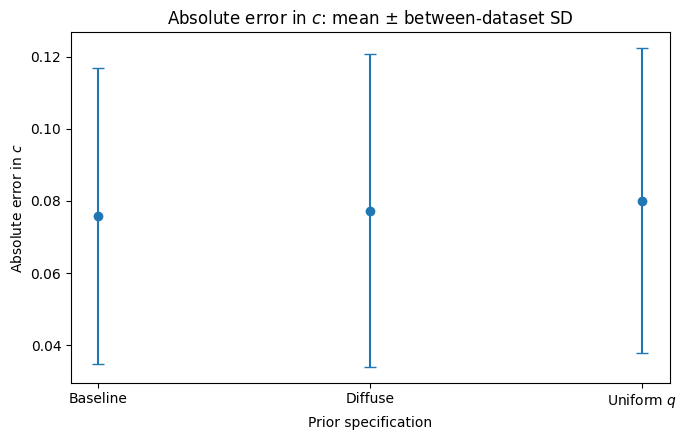

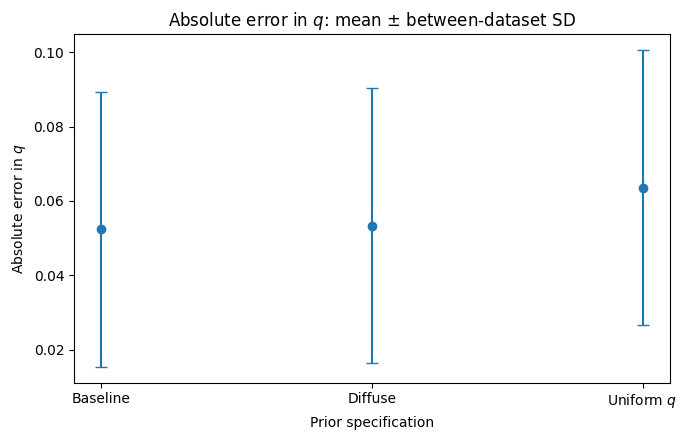

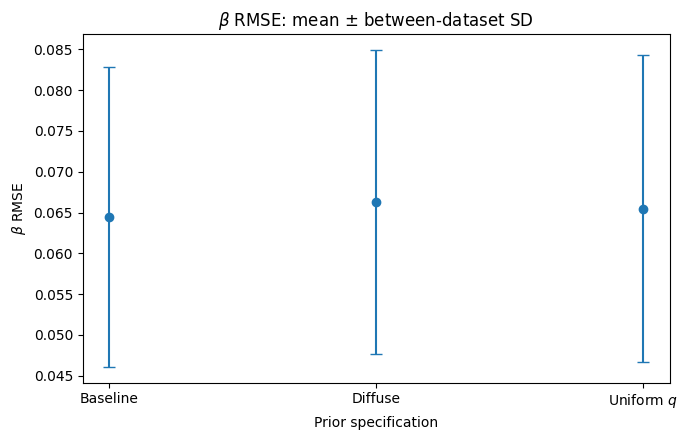

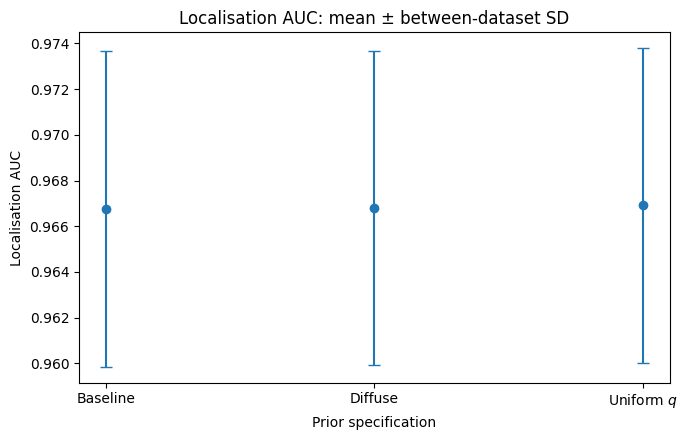

In [9]:
# Use the same ordering in each plot.
prior_order = [
    p for p in PRIOR_SPECS
    if p in results["prior"].unique()
]

prior_labels = {
    "baseline": "Baseline",
    "diffuse": "Diffuse",
    "q_uniform": r"Uniform $q$",
}


def mean_sd_plot(metric, ylabel, filename):
    # Summarise variation across the 10 paired datasets for each prior.
    means = [
        results.loc[results["prior"] == p, metric].mean()
        for p in prior_order
    ]
    sds = [
        results.loc[results["prior"] == p, metric].std(ddof=1)
        for p in prior_order
    ]

    labels = [prior_labels[p] for p in prior_order]

    fig, ax = plt.subplots(figsize=(7, 4.5))

    # Error bars show between-dataset SD, not uncertainty in the mean.
    ax.errorbar(
        labels,
        means,
        yerr=sds,
        fmt="o",
        capsize=4,
    )

    ax.set_ylabel(ylabel)
    ax.set_xlabel("Prior specification")
    ax.set_title(f"{ylabel}: mean ± between-dataset SD")

    fig.tight_layout()
    fig.savefig(
        FIG_DIR / filename,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


mean_sd_plot(
    "c_abs_error",
    r"Absolute error in $c$",
    "prior_sensitivity_c_error.png",
)

mean_sd_plot(
    "q_abs_error",
    r"Absolute error in $q$",
    "prior_sensitivity_q_error.png",
)

mean_sd_plot(
    "beta_rmse",
    r"$\beta$ RMSE",
    "prior_sensitivity_beta_rmse.png",
)

mean_sd_plot(
    "localisation_auc",
    "Localisation AUC",
    "prior_sensitivity_auc.png",
)

## Running-mean stability check

The running means show how the average sensitivity estimates change as additional paired datasets are included. They provide a simple check of whether the reported summaries are settling over the 10 replicates.

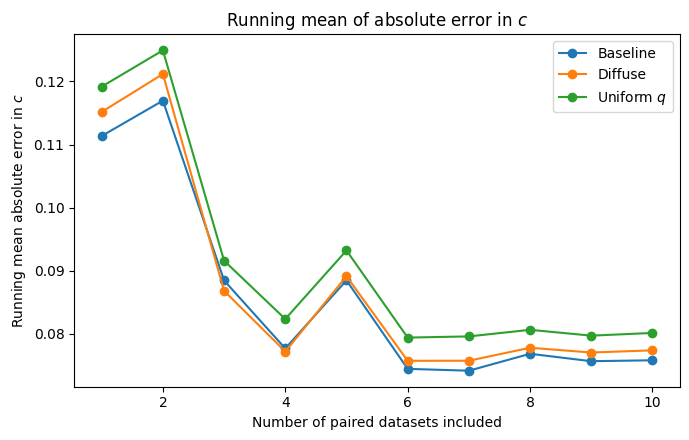

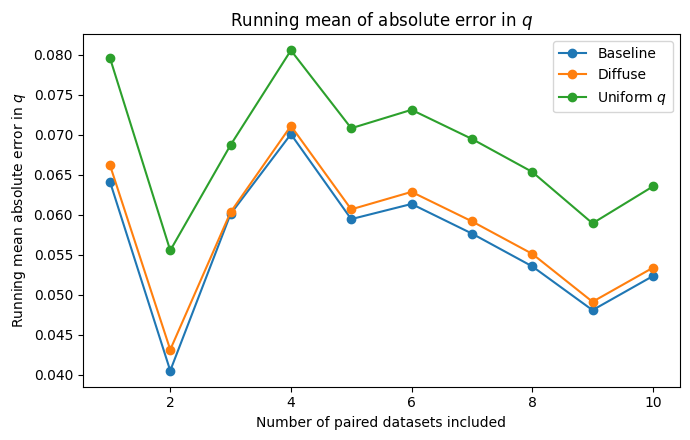

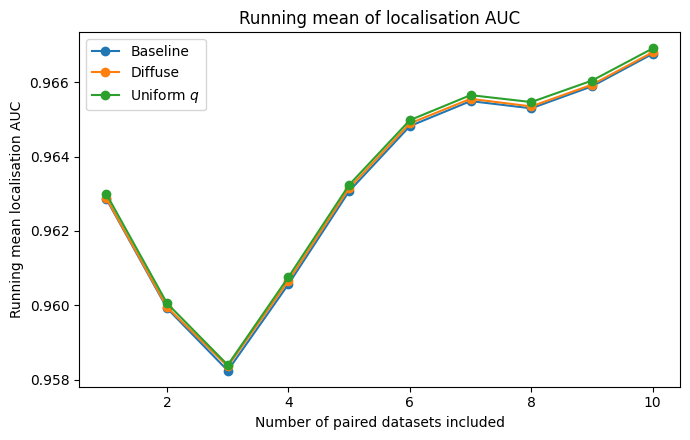

In [10]:
def running_mean_plot(metric, ylabel, filename):
    fig, ax = plt.subplots(figsize=(7, 4.5))

    # Add datasets in replicate order and track how the mean settles.
    for prior_name in prior_order:
        g = (
            results.loc[
                results["prior"] == prior_name,
                ["rep", metric],
            ]
            .sort_values("rep")
            .dropna()
        )

        if len(g) == 0:
            continue

        running = g[metric].expanding().mean()

        ax.plot(
            g["rep"],
            running,
            marker="o",
            label=prior_labels[prior_name],
        )

    ax.set_xlabel("Number of paired datasets included")
    ax.set_ylabel(f"Running mean {ylabel}")
    ax.set_title(f"Running mean of {ylabel}")
    ax.legend()

    fig.tight_layout()
    fig.savefig(
        FIG_DIR / filename,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


running_mean_plot(
    "c_abs_error",
    r"absolute error in $c$",
    "running_mean_c_error.png",
)

running_mean_plot(
    "q_abs_error",
    r"absolute error in $q$",
    "running_mean_q_error.png",
)

running_mean_plot(
    "localisation_auc",
    "localisation AUC",
    "running_mean_auc.png",
)

## Diagnostic failures

Prior-sensitivity results are interpreted only for fits that pass the prespecified MCMC diagnostic gate. The table below lists any fits that fail these checks.

In [11]:
# Pull out any fits that fail the diagnostic gate.
failed = results.loc[
    ~results["diagnostic_pass"].astype(bool),
    [
        "rep",
        "prior",
        "max_rhat",
        "min_bulk_ess",
        "divergences",
        "treedepth_hits",
    ],
]

if len(failed):
    display(failed)
else:
    print(
        "All prior-sensitivity fits pass the prespecified diagnostic gate."
    )

All prior-sensitivity fits pass the prespecified diagnostic gate.
